# 3. Exploratory Data Analysis (EDA)

**Tasks**:

- Use `seaborn`, `matplotlib`, `plotly`, or `pandas_profiling`
- Plot distributions, correlations, boxplots
- Use pairplots to see clusters visually (especially on 2–3 variables)

**Tips**:

- Visual storytelling helps your GitHub project stand out
- Add markdown cells in your notebook to explain what you're doing

## 3.1. Discovering data distribution

First step, is the loading the cleaned dataset from previous step.

In [1]:
import matplotlib.pyplot as plt # Data visualization
import matplotlib.patheffects as pe
import seaborn as sns # Data visualization
import numpy as np # linear algebra
import pandas as pd # Data processing

import missingno as msno # Analyze data for missing values

In [2]:
raw_data_directory_path = r"D:/Google Drive/Work/Data Analytics and Data Science/Roadpam/project_1-customer-segmentation/data/raw"
processed_data_directory_path = r"D:/Google Drive/Work/Data Analytics and Data Science/Roadpam/project_1-customer-segmentation/data/processed"

In [3]:
df = pd.read_csv(str(processed_data_directory_path) + "/e-commerce-data-cleaned.csv", encoding = 'latin1', index_col = 0)
df

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2010-12-01,08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2010-12-01,08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,2011-12-09,12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2011-12-09,12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,2011-12-09,12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,2011-12-09,12:50:00,4.15,12680.0,France


The initial phase of the EDA process in this project will involve constructing the plot distribution across variables. Firstly, the following will be analysed based on with the nature of the variable data:
1. *customer_id* - to see the distribution of customers' activity;
2. *stock_code* - to see the distribution of how often the specific good or group of goods is ordered;
3. *invoice_datetime* and *invoice_date* - to analyse the distribution of orders by date and time, and identify the most active periods;
4. *country* - to analyse the the most active clients by country.

Perhaps the following could be tried:
1. Group the *quantity* column into several order size categories, such as “small order,” “medium order,” and “large order.” Then visualize the distribution across these categories.
2. Group the *customer_id* column into several categories based on customer activity, maybe create bins of the number of orders, for example, "< 10" orders, "10-15", and so on. Then visualize the distribution of histogram for this bins.

### 3.1.1. Distribution of *customer_id*
First, start with the *customer_id*, build the distribution chart to understand the pattern of customer activity.

For this, first, determine how many times each customer (*customer_id*) appears in the dataset.

In [4]:
idx = pd.Index(df['customer_id'])
custumer_counts = idx.value_counts()
custumer_counts

customer_id
17841.0    7667
14911.0    5584
14096.0    5095
12748.0    4397
14606.0    2674
           ... 
16881.0       1
12791.0       1
13747.0       1
13703.0       1
13188.0       1
Name: count, Length: 4334, dtype: int64

Once the new data has been received, it becomes possible to examine the summary statistics for the *customer_id* column. This procedure was performed earlier, but now it is being done on the cleaned data.

In [5]:
custumer_counts.describe().T

count    4334.000000
mean       90.232580
std       224.707914
min         1.000000
25%        17.000000
50%        41.000000
75%        98.000000
max      7667.000000
Name: count, dtype: float64

For a more accurate analysis, we also calculate the summary statistics for the column in its original format.

In [6]:
df['customer_id'].describe().T

count    391068.000000
mean      15295.134849
std        1710.345760
min       12346.000000
25%       13969.000000
50%       15158.000000
75%       16794.000000
max       18287.000000
Name: customer_id, dtype: float64

Since the data was imported as numeric values again, the data in this column is being converted to the `object` format.

In [7]:
df['customer_id'] = df['customer_id'].astype('object')
df['customer_id'].describe(include = 'object').T

count     391068.0
unique      4334.0
top        17841.0
freq        7667.0
Name: customer_id, dtype: float64

As is evident, even following the process of data cleansing, the distribution remains skewed, as there are still users with abnormally high activity levels. For instance, customer with ID $17841$ has an activity frequency of $7667$, which differs significantly from both the mean and the median.

To determine whether this is an outlier and if there are other similar customers, as previously mentioned, it is necessary to plot a distribution graph.

In [8]:
customer_mean = np.mean(custumer_counts)
customer_std = np.std(custumer_counts)

print("mean =", customer_mean, "\nstd = ", customer_std)

mean = 90.23257960313798 
std =  224.68198905716062


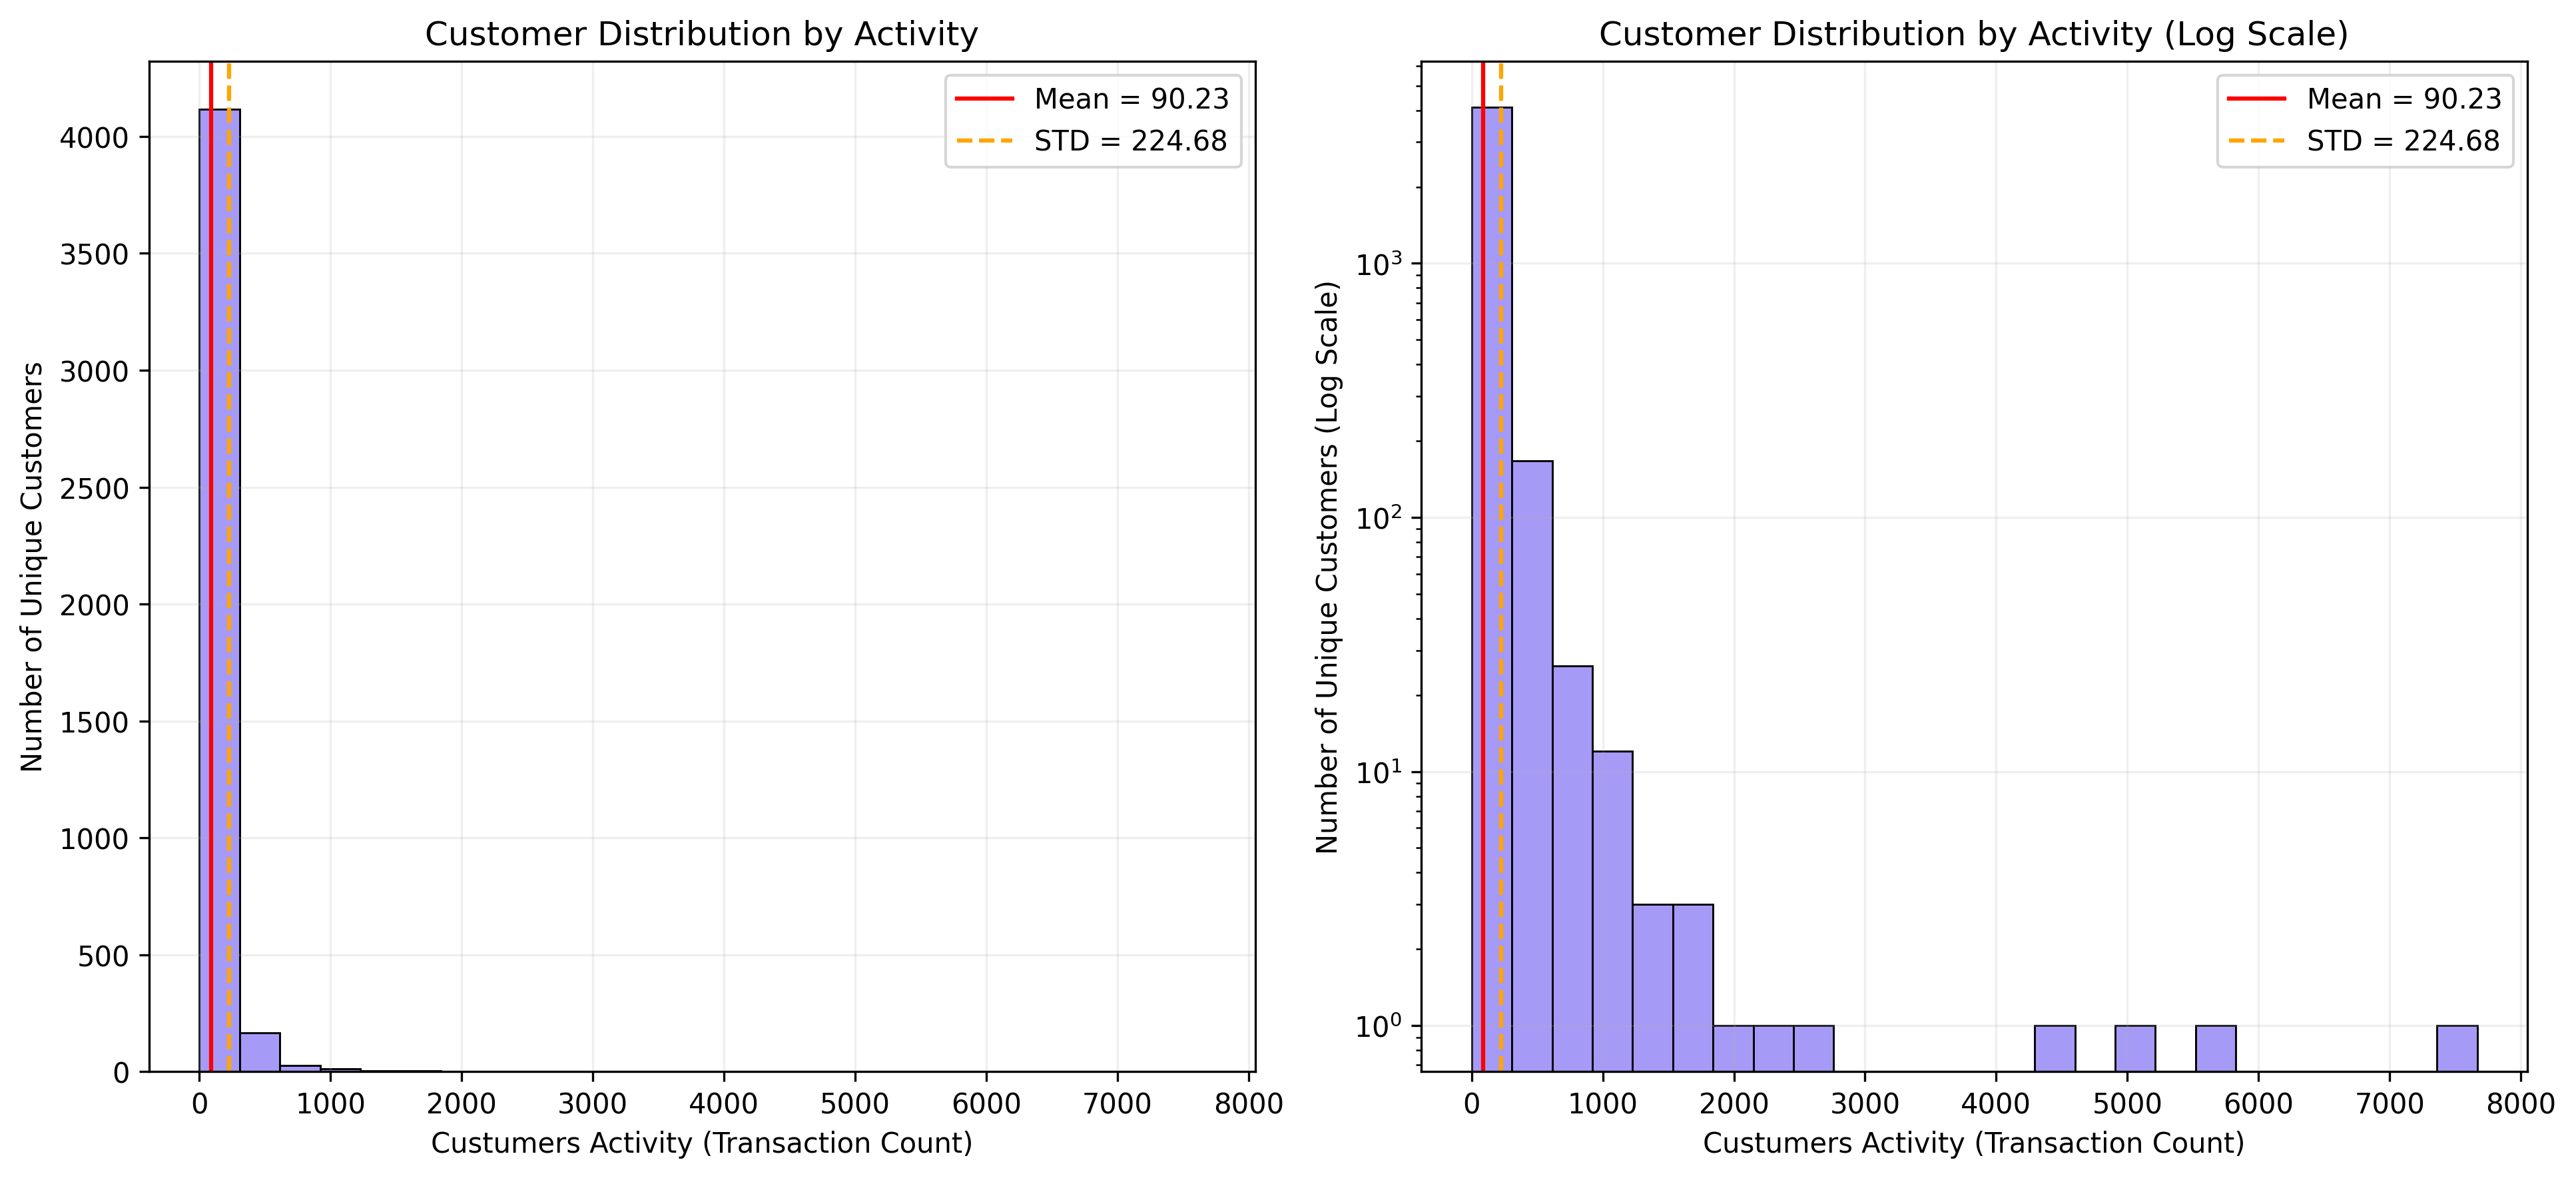

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (13, 6), dpi = 300)

#============ Plot 1 ==========
sns.histplot(custumer_counts, bins = 25, ax = ax1, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax1.axvline(customer_mean, color = 'red', label = f'Mean = {customer_mean:.2f}')
ax1.axvline(customer_std, color = 'orange', ls = '--', label = f'STD = {customer_std:.2f}')

ax1.set_title('Customer Distribution by Activity')
ax1.set_xlabel('Custumers Activity (Transaction Count)')
ax1.set_ylabel('Number of Unique Customers')
ax1.legend()
ax1.grid(alpha = 0.2)

#============ Plot 2 ==========
sns.histplot(custumer_counts, bins = 25, ax = ax2, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax2.axvline(customer_mean, color = 'red', label = f'Mean = {customer_mean:.2f}')
ax2.axvline(customer_std, color = 'orange', ls = '--', label = f'STD = {customer_std:.2f}')

ax2.set_yscale('log')

ax2.set_title('Customer Distribution by Activity (Log Scale)')
ax2.set_xlabel('Custumers Activity (Transaction Count)')
ax2.set_ylabel('Number of Unique Customers (Log Scale)')
ax2.legend()
ax2.grid(alpha = 0.2)


plt.tight_layout() # Prevents labels from overlapping
plt.show()

At this stage, all data points are assumed to be important and valid. But to assess the distribution in greater detail, the interquartile range and the lower and upper thresholds will be calculated. Data points beyond these thresholds are classified as outliers and are subject to winsorization. Based on the results of the winsorization, a decision will be made on how to handle outliers.

To get the lower and upper thresholds the more robust and common way is to use the interquartile range and multiply it by $1.5$. Then this result is subtracted from the $25th$ percentile and added to the $75th$. This can be expressed using the following equations:

$$Lower\_threshold = 25\_percentile - (1.5 * IQR)$$
$$Upper\_threshold = 75\_percentile + (1.5 * IQR)$$

where:

$$IQR = 75\_percentile - 25\_percentile$$

In [10]:
customer_25_percentile = np.percentile(custumer_counts, 25)
customer_75_percentile = np.percentile(custumer_counts, 75)

customer_IQR = customer_75_percentile - customer_25_percentile

customer_lower_threshold = customer_25_percentile - (1.5 * customer_IQR)
customer_upper_threshold = customer_75_percentile + (1.5 * customer_IQR)

print("Parameters for identifying outliers")
print("\n25 percentile =", customer_25_percentile,
      "\n75 percentile =", customer_75_percentile,
      "\nIQR =", customer_IQR,
      "\nLower threshold =", customer_lower_threshold,
      "\nUpper threshold =", customer_upper_threshold)

Parameters for identifying outliers

25 percentile = 17.0 
75 percentile = 98.0 
IQR = 81.0 
Lower threshold = -104.5 
Upper threshold = 219.5


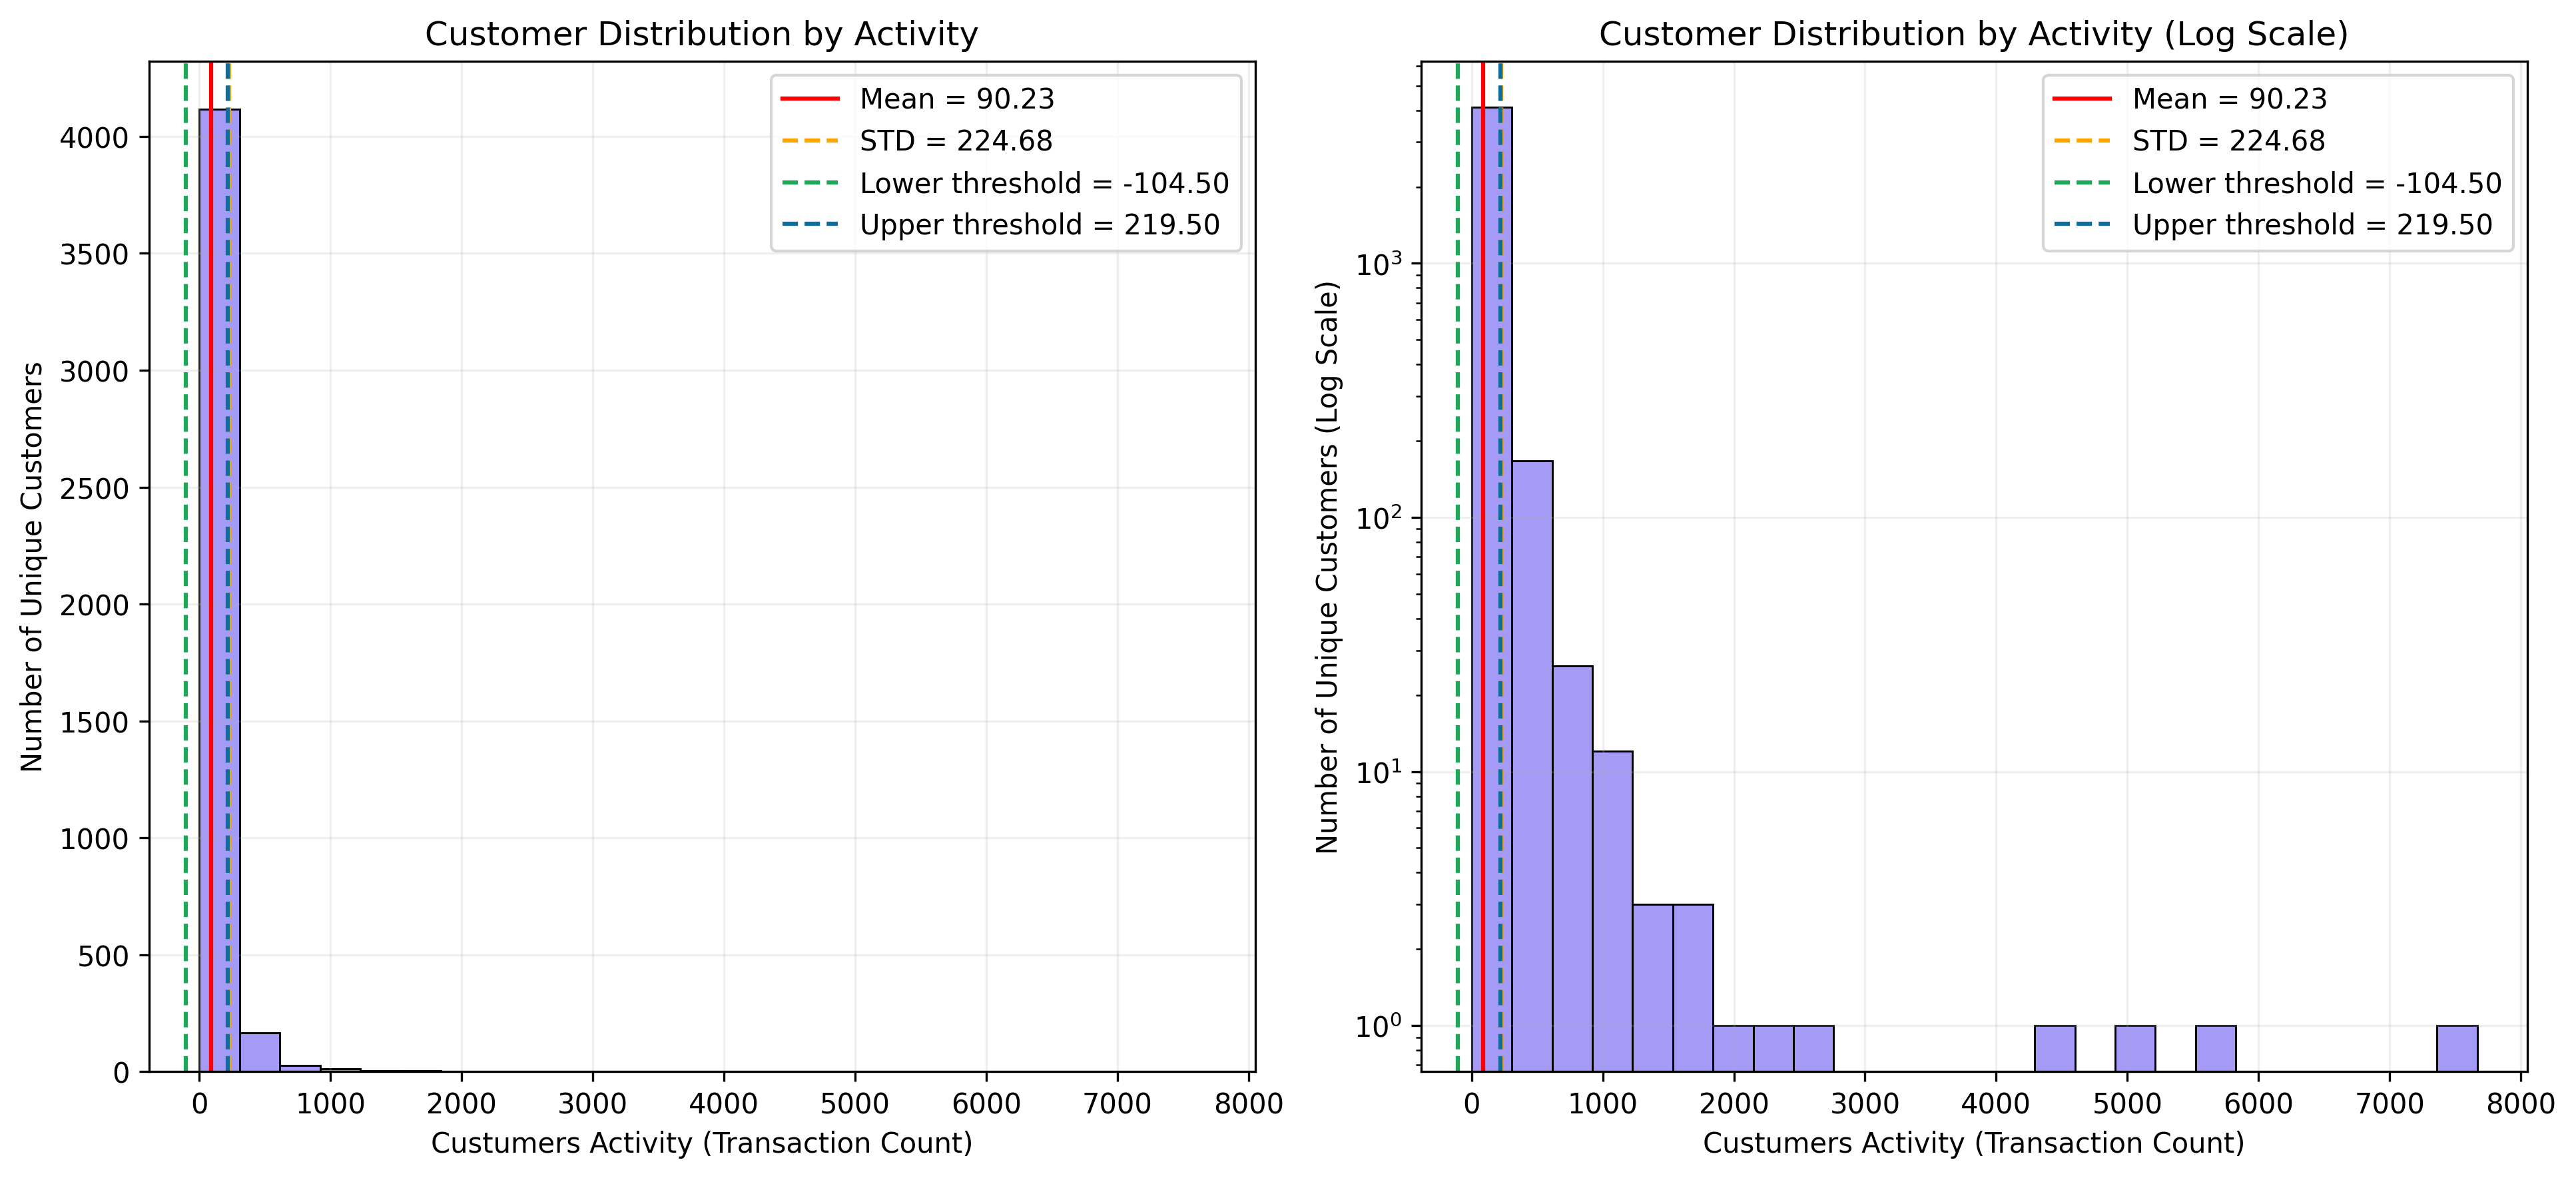

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (13, 6), dpi = 300)

#============ Plot 1 ==========
sns.histplot(custumer_counts, bins = 25, ax = ax1, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax1.axvline(customer_mean, color = 'red', label = f'Mean = {customer_mean:.2f}')
ax1.axvline(customer_std, color = 'orange', ls = '--', label = f'STD = {customer_std:.2f}')
ax1.axvline(customer_lower_threshold, color = '#1ea659', ls = '--', label = f'Lower threshold = {customer_lower_threshold:.2f}')
ax1.axvline(customer_upper_threshold, color = '#0d6e9e', ls = '--', label = f'Upper threshold = {customer_upper_threshold:.2f}')

ax1.set_title('Customer Distribution by Activity')
ax1.set_xlabel('Custumers Activity (Transaction Count)')
ax1.set_ylabel('Number of Unique Customers')
ax1.legend()
ax1.grid(alpha = 0.2)

#============ Plot 2 ==========
sns.histplot(custumer_counts, bins = 25, ax = ax2, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax2.axvline(customer_mean, color = 'red', label = f'Mean = {customer_mean:.2f}')
ax2.axvline(customer_std, color = 'orange', ls = '--', label = f'STD = {customer_std:.2f}')
ax2.axvline(customer_lower_threshold, color = '#1ea659', ls = '--', label = f'Lower threshold = {customer_lower_threshold:.2f}')
ax2.axvline(customer_upper_threshold, color = '#0d6e9e', ls = '--', label = f'Upper threshold = {customer_upper_threshold:.2f}')

ax2.set_yscale('log')

ax2.set_title('Customer Distribution by Activity (Log Scale)')
ax2.set_xlabel('Custumers Activity (Transaction Count)')
ax2.set_ylabel('Number of Unique Customers (Log Scale)')
ax2.legend()
ax2.grid(alpha = 0.2)


plt.tight_layout() # Prevents labels from overlapping
plt.show()

As is evident, the range of data between the upper and lower thresholds is relatively limited. In order to guarantee that all details are considered in the analysis, the subsequent step is to implement the winsorization process. This involves replacing data points that fall outside the 5th and 95th percentiles with values that correspond to those percentiles. The value of $1.5$ is taken based on the **1.5 IQR** rule which is a statistical method used for identiying outliers in a dataset.
That is:

$$ IF\ value < 5th\ percentile\ THEN\ value\ = 5th\ percentile$$
$$ IF\ value > 95th\ percentile\ THEN\ value\ = 95th\ percentile$$

The interquartile (IQR) method of outlier detection uses $1.5$ as its scale to detect outliers because it most closely follows Gaussian distribution. As a result, the method dictates that any data point that’s 1.5 points below the lower bound quartile or above the upper bound quartile is an outlier.

As the distribution graph is left-skewed in this case, there is no need to perform lower-limit winsorization.

In [12]:
upper_limit = np.percentile(custumer_counts, 95)

custumer_counts_winsored = custumer_counts.clip(upper = upper_limit)

custumer_counts_winsored

customer_id
17841.0    308
14911.0    308
14096.0    308
12748.0    308
14606.0    308
          ... 
16881.0      1
12791.0      1
13747.0      1
13703.0      1
13188.0      1
Name: count, Length: 4334, dtype: int64

Before plotting new graphs, the mean and median values for the updated data will be calculated.

In [13]:
ustomer_winsored_mean = np.mean(custumer_counts_winsored)
customer_winsored_std = np.std(custumer_counts_winsored)

print("mean =", ustomer_winsored_mean, "\nstd = ", customer_winsored_std)

mean = 73.81287494231657 
std =  82.3783062154598


Given that winsorization has relieved the outliers (extreme values) from the distribution graph, the second graph on a logarithmic scale is no longer necessary 

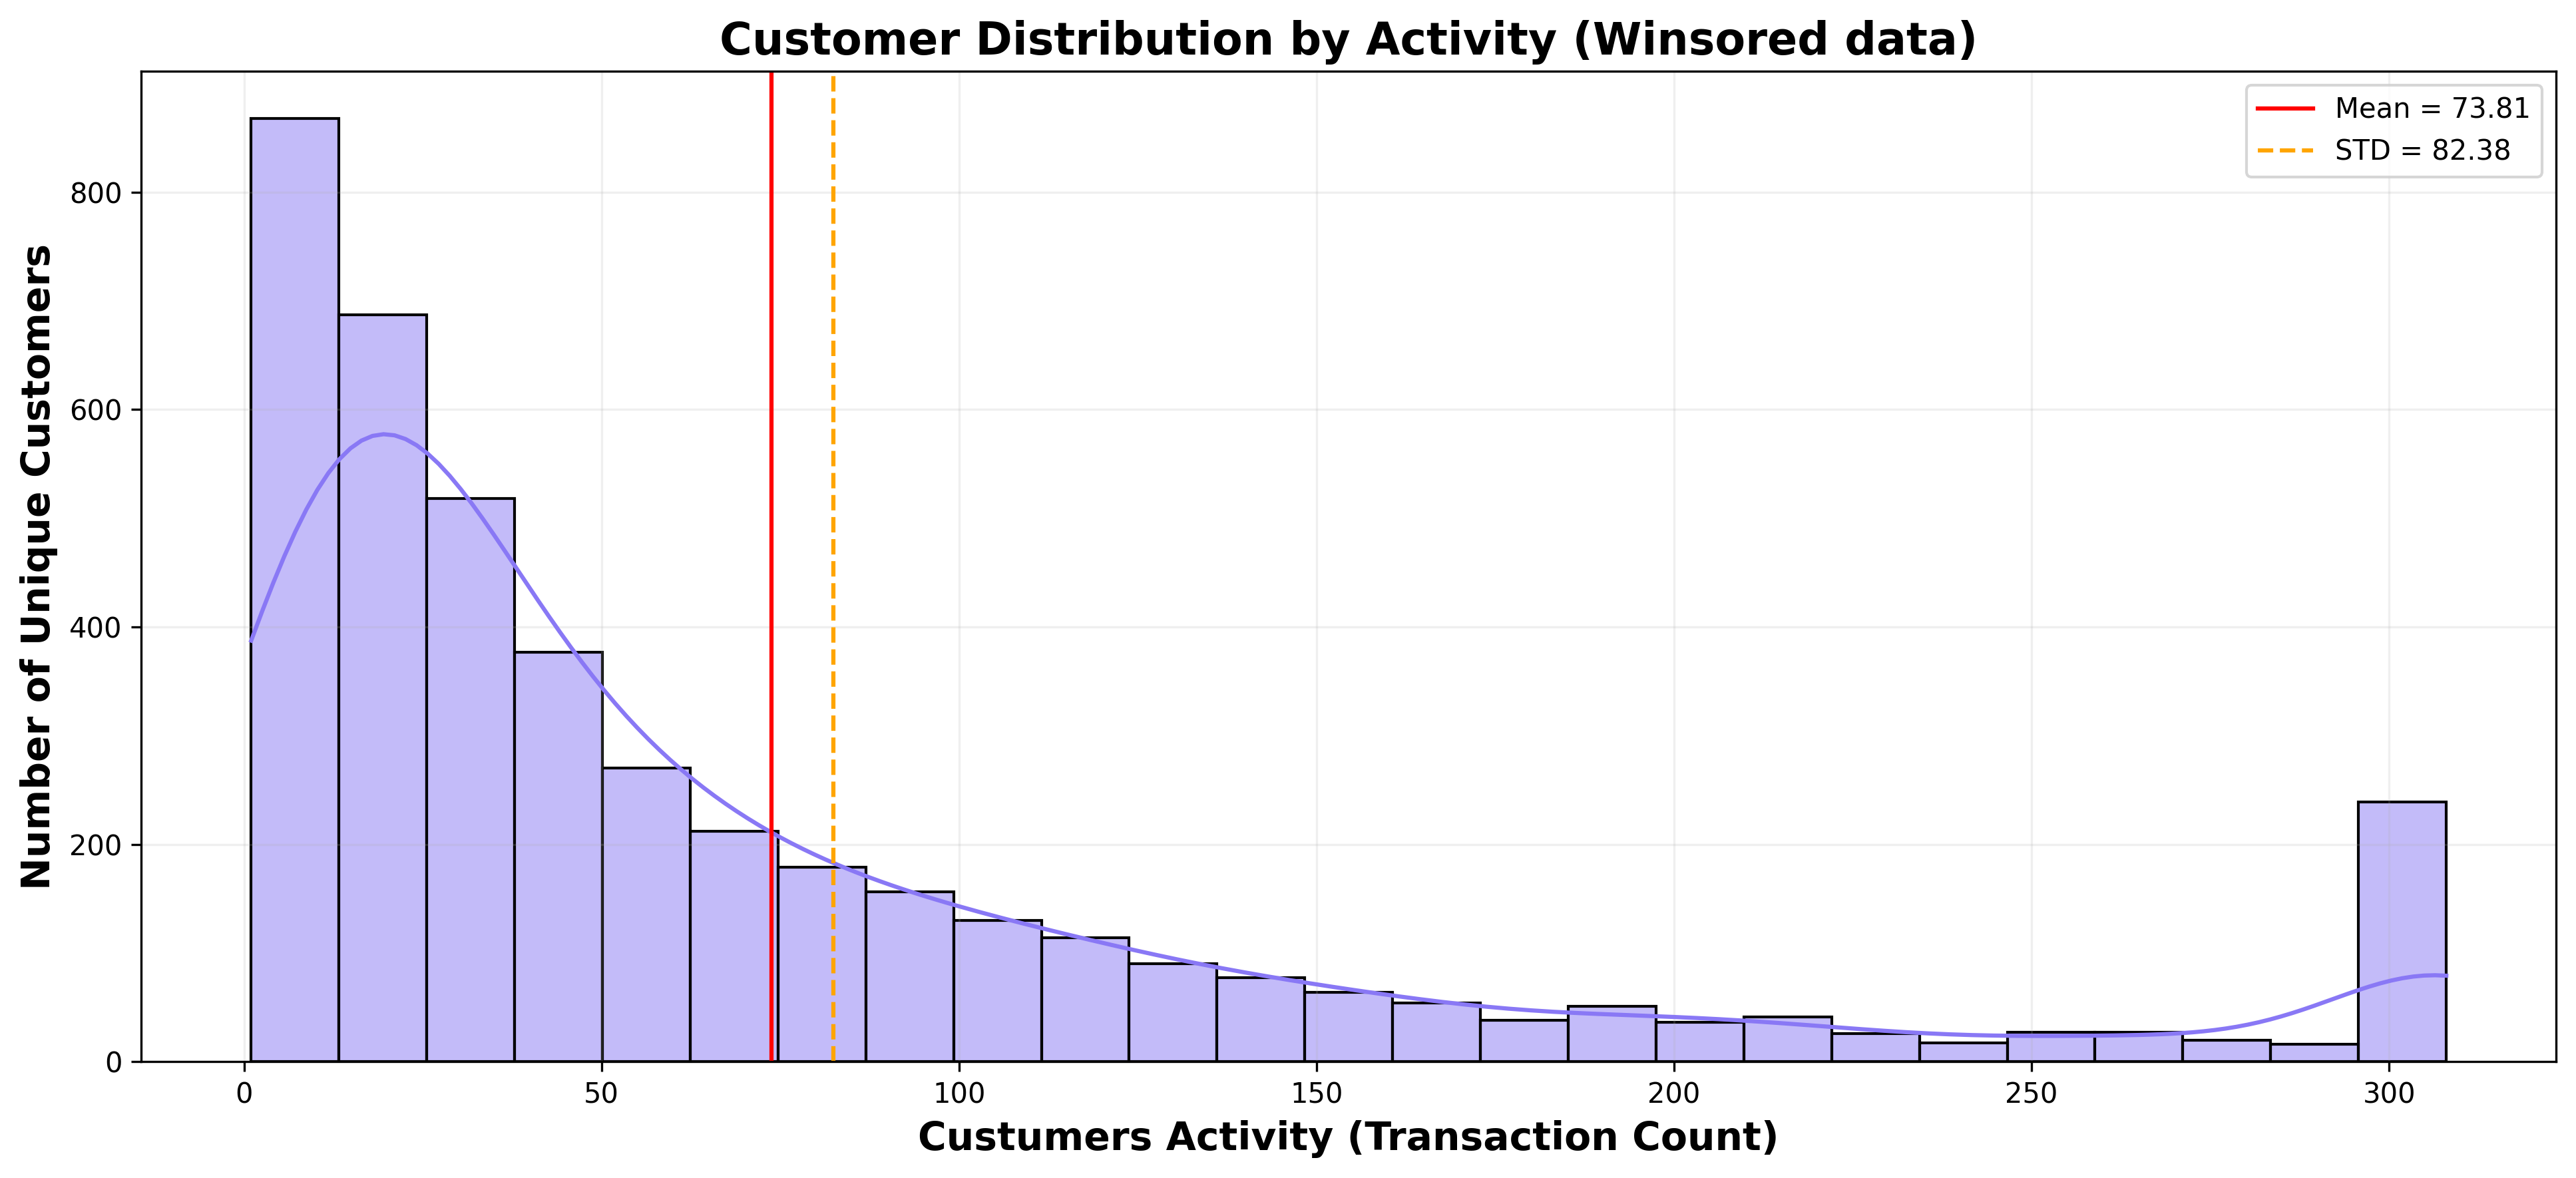

In [20]:
fig, ax = plt.subplots(figsize = (13, 6), dpi = 300)

#============ Plot 1 ==========
sns.histplot(custumer_counts_winsored, bins = 25, ax = ax, kde = True, color = '#8978f5', edgecolor = 'black', linewidth = 1)
ax.axvline(ustomer_winsored_mean, color = 'red', label = f'Mean = {ustomer_winsored_mean:.2f}')
ax.axvline(customer_winsored_std, color = 'orange', ls = '--', label = f'STD = {customer_winsored_std:.2f}')

ax.set_title('Customer Distribution by Activity (Winsored data)', fontweight = 'bold', fontsize = 16)
ax.set_xlabel('Custumers Activity (Transaction Count)', fontweight = 'bold', fontsize = 14)
ax.set_ylabel('Number of Unique Customers', fontweight = 'bold', fontsize = 14)
ax.legend()
ax.grid(alpha = 0.2)

plt.tight_layout()
plt.show()

It would be useful to know how many users underwent the winsorization process. According to the results, it was $215$ unique customers.

In [15]:
diff_mask = custumer_counts != custumer_counts_winsored
changed_count = diff_mask.sum()

print(f"Number of customers subjected to winsorization: {changed_count}")

Number of customers subjected to winsorization: 215


In order to gain a more comprehensive understanding of the impact of the winsorization procedure on the statistical parameters, a comparison will be conducted between the corrected data and the original data.

In [16]:
original_stats = custumer_counts.describe()
winsored_stats = custumer_counts_winsored.describe()

# Concatenate descriptions along columns (axis=1)
comparison_df = pd.concat([original_stats, winsored_stats], axis=1)

comparison_df.columns = ['Original Data', 'Winsorized (95th)']
print(comparison_df)

       Original Data  Winsorized (95th)
count    4334.000000        4334.000000
mean       90.232580          73.812875
std       224.707914          82.387812
min         1.000000           1.000000
25%        17.000000          17.000000
50%        41.000000          41.000000
75%        98.000000          98.000000
max      7667.000000         308.000000


As can be seen, the data has been successfully normalized. This is particularly evident when comparing the mean and median values. As a result, it was successfully analyzed how customers were distributed by activity level, while retaining data on customers with abnormally high activity and not deleting it.

As can be seen from the last graphs, the distribution of customer activity, as previously described, is right-skewed (positive asymmetry), but this conclusion is now definitively confirmed. This result indicates that the majority of clients are customers with a relatively low order frequency. For future customer segmentation, users can be divided into the following groups based on order frequency:
- **Low activity** - $0-100$;
- **Moderate activity** - $100-300$;
- **High activity** - $Over\ 300$.

The final step will be to select users who have been subject to winsorization and place them into a separate dataset that can be used later.

In [17]:
# using the upper_limit (the 95th percentile) to identify the IDs that extend beyond the upper limit
custumer_counts_winsored_ids = custumer_counts[custumer_counts > upper_limit].index

custumer_winsored = df[df['customer_id'].isin(custumer_counts_winsored_ids)]
custumer_winsored

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
86,536378,22386,JUMBO BAG PINK POLKADOT,10,2010-12-01 09:37:00,2010-12-01,09:37:00,1.95,14688.0,United Kingdom
87,536378,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,2010-12-01 09:37:00,2010-12-01,09:37:00,1.95,14688.0,United Kingdom
88,536378,21033,JUMBO BAG CHARLIE AND LOLA TOYS,10,2010-12-01 09:37:00,2010-12-01,09:37:00,2.95,14688.0,United Kingdom
89,536378,20723,STRAWBERRY CHARLOTTE BAG,10,2010-12-01 09:37:00,2010-12-01,09:37:00,0.85,14688.0,United Kingdom
90,536378,84997B,RED 3 PIECE RETROSPOT CUTLERY SET,12,2010-12-01 09:37:00,2010-12-01,09:37:00,3.75,14688.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...
541860,581581,23562,SET OF 6 RIBBONS PERFECTLY PRETTY,6,2011-12-09 12:20:00,2011-12-09,12:20:00,2.89,17581.0,United Kingdom
541861,581581,23561,SET OF 6 RIBBONS PARTY,6,2011-12-09 12:20:00,2011-12-09,12:20:00,2.89,17581.0,United Kingdom
541862,581581,23681,LUNCH BAG RED VINTAGE DOILY,10,2011-12-09 12:20:00,2011-12-09,12:20:00,1.65,17581.0,United Kingdom
541863,581582,23552,BICYCLE PUNCTURE REPAIR KIT,6,2011-12-09 12:21:00,2011-12-09,12:21:00,2.08,17581.0,United Kingdom


In [18]:
total_custumer_winsored = custumer_winsored.shape[0]
percentage_custumer_winsored = float((total_custumer_winsored / df.shape[0]) * 100)

print(f"\nNumber of users underwent the winsorization process {total_custumer_winsored} ({percentage_custumer_winsored:.2f}%) records")


Number of users underwent the winsorization process 137383 (35.13%) records



The following results were obtained from an analysis of the distribution of parameter `cutomer_id`:
1. The activity of $215$ users was smoothed out using Winsorisation. This was because their activity levels were unusually high compared to other users, making it difficult to analyse the distribution accurately.
2. These $215$ customers account for $137383\ (35.13\%)$ transaction records in the dataset.

Saving the obtained dataset of high activity customers in a separate file for possible further use or deeper sub-EDA analysis..

In [19]:
custumer_winsored.to_csv(str(processed_data_directory_path) + "/e-commerce-data-winsored-customer-activity.csv")

### 3.1.2. Discovering of *stock_code*

When devided date/time column, answer for:
    - Seasonality: Which months have the highest sales?
    - Weekly Patterns: Do customers shop more on weekends?
    - Daily Cycles: What is the "peak hour" for orders?